In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
text_emb_128 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_128.parquet'

RANDOM_STATE = 42

Project root: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1
Data: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\data\exploded_splits


# KNN based Model - on textual embeddings
By leveraging textual embeddings (128-dimensional vectors representing paper content), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `KNNModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with embedding

In [2]:
df = pd.read_parquet(text_emb_128)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029547,0.027875,-0.039097,0.061652,...,0.064212,0.001819,0.028266,0.074405,-0.012687,-0.012413,-0.018658,0.019843,-0.018603,-0.062412
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009653,-0.006376,0.139197,0.036759,0.024399,...,-0.002640,0.002758,-0.021711,0.000173,0.036031,0.010025,-0.032560,-0.004902,0.012356,-0.037394
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.025537,0.005557,0.027970,0.036103,0.017138,-0.040106,0.029802,-0.020301,-0.001983,-0.039484
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,0.022904,0.030194,0.019120,-0.022178,-0.037727,0.054251,-0.055143,0.056518,-0.040537,-0.131712
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.028705,-0.019178,-0.046387,-0.040602,0.018601,0.018564,0.042588,0.064933,0.001457,0.016216


(2950135, 260)


In [3]:
# splitting
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}


## 2. Baseline Model

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN] Starting training...
              precision    recall  f1-score   support

           0     0.9551    0.7798    0.8586       109
           1     0.8110    0.9626    0.8803       107

    accuracy                         0.8704       216
   macro avg     0.8830    0.8712    0.8695       216
weighted avg     0.8837    0.8704    0.8694       216



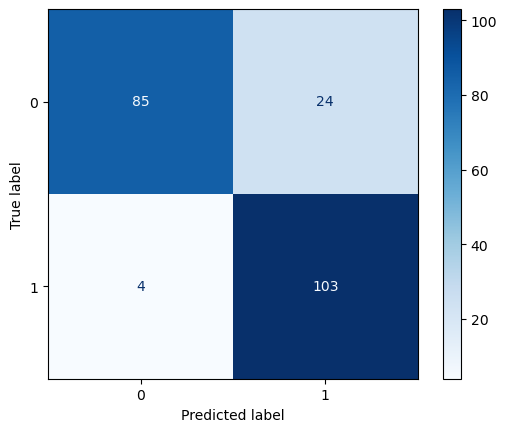

In [4]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski')
KNN_baseline = KNNModel()

KNN_baseline.train_pipeline(df_train, frac=0.0001)

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
0    0.5036
1    0.4964
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7335    0.6833    0.7075      5036
           1     0.6996    0.7482    0.7231      4964

    accuracy                         0.7155     10000
   macro avg     0.7165    0.7157    0.7153     10000
weighted avg     0.7167    0.7155    0.7152     10000



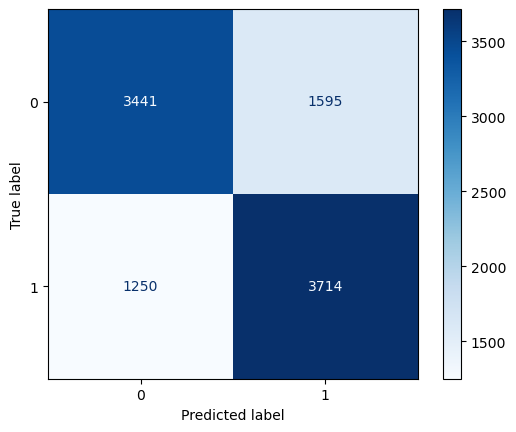

In [5]:
KNN_baseline.test_pipeline(df_test.sample(10000))

## 3. Hypertuning
Given the high dimensionality of embeddings and the large number of records, KNN can be computationally expensive. To optimize performance, we perform `GridSearchCV` on a representative subset of the data.

We utilize a `PredefinedSplit` strategy. Instead of standard K-fold cross-validation, we manually specify which samples belong to the training fold and which belong to the validation fold. This ensures that the model is tuned on the exact data distribution intended for validation without leakage from the training set.

In [6]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [7]:
# tuning
tuner_model = KNNModel() # model to preprocess data
X_train_scaled, y_train = tuner_model.preprocess(df_train, is_training=True)
X_val_scaled, y_val = tuner_model.preprocess(df_val, is_training=False)

# Downsampling for speed
def downsample_indices(indices, n_samples):
    if len(indices) > n_samples:
        return np.random.choice(indices, n_samples, replace=False)
    return indices

train_tuning_idx = downsample_indices(np.arange(len(X_train_scaled)), int(max_tuning_samples * 0.8))
val_tuning_idx = downsample_indices(np.arange(len(X_val_scaled)), int(max_tuning_samples * 0.2))

X_subset = np.vstack((X_train_scaled[train_tuning_idx], X_val_scaled[val_tuning_idx]))
y_subset = np.concatenate((y_train.iloc[train_tuning_idx], y_val.iloc[val_tuning_idx]))

# Create split indices: -1 for train, 0 for validation
split_index = np.concatenate([-1 * np.ones(len(train_tuning_idx)), 0 * np.ones(len(val_tuning_idx))])
ps = PredefinedSplit(test_fold=split_index)

# GridSearchCV
print(f"Starting tuning on {len(X_subset)} samples...")
grid_search = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid,
    cv=ps,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_search.fit(X_subset, y_subset)

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
Starting tuning on 50000 samples...


OSError: [WinError 1450] Risorse di sistema insufficienti per completare il servizio richiesto

In [ ]:
best_params = grid_search.best_params_
print("\nBest parameters found:")
print(best_params)

# Final training on the full dataset with the best parameters
model = grid_search.best_estimator_
model.fit(X_train_scaled, y_train)

print(f"\nOptimal model ready: {model}")

## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

In [ ]:
# final training creating model with best params
final_knn = KNNModel("KNN_textual", **best_params)

print(f'Train model with best params...')
final_knn.train_pipeline(df_train)


Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 12, 'weights': 'uniform'}
[KNN_textual] Preprocessing data...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN_textual] Starting training...


In [ ]:
final_knn.test_pipeline(df_test)

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [ ]:
df_name = "knn_textual_embeddings_128"
model_family = "knn"
model_name = "knn_classifier"
split_name = "predefined_train_validation_test"
summary = {
        "scoring": "f1_weighted",
        "max_tuning_samples": int(max_tuning_samples),
        "train_subset_size": int(len(train_tuning_idx)),
        "val_subset_size": int(len(val_tuning_idx)),
    },

final_knn.save_model(params = best_params, df_name=df_name, model_family=model_family, split_name=split_name, summary=summary, force=False)